Question 1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

def get_column(data, index):
  result = [row[index] for row in data]
  return result

def prepare_data(file_name_dataset):
  data = np.genfromtxt(file_name_dataset, delimiter=',', skip_header=1).tolist()
  N = len(data)

  tv_data = get_column(data, 0)

  radio_data = get_column(data, 1)

  newspaper_data = get_column(data, 2)

  sales_data = get_column(data, 3)

  X = [tv_data, radio_data, newspaper_data]
  y = sales_data
  return X,y

In [6]:
X,y = prepare_data('/content/drive/MyDrive/advertising.csv')
list = [sum(X[0][:5]), sum(X[1][:5]), sum(X[2][:5]), sum(y[:5])]
print(list)

[624.1, 175.10000000000002, 300.5, 78.9]


Question 2

In [8]:
def initialize_params () :
  w1 = random.gauss(mu=0.0, sigma =0.01)
  w2 = random.gauss(mu=0.0, sigma =0.01)
  w3 = random.gauss(mu=0.0, sigma =0.01)
  b = 0
  return w1, w2 , w3 , b

In [9]:
def initialize_params () :
  w1, w2, w3, b = (0.016992259082509283, 0.0070783670518262355, -0.002307860847821344, 0)
  return w1, w2, w3, b

In [11]:
def predict ( x1 , x2 , x3 , w1 , w2 , w3 , b ) :
  return w1*x1 + w2*x2 + w3*x3 + b

In [12]:
def compute_loss_mse(y_hat, y):
  return (y_hat - y)**2

In [13]:
def compute_gradient_wi(xi, y, y_hat):
  dl_dwi = 2*xi*(y_hat - y);
  return dl_dwi

In [14]:
def compute_gradient_b(y, y_hat):
  dl_db = 2*(y_hat - y);
  return dl_db

In [17]:
def implement_linear_regression(X_data, y_data, epoch_max = 50, lr = 0.00001):
  losses = []

  w1, w2, w3, b = initialize_params()

  N = len(y_data)
  for epoch in range (epoch_max):
    for i in range(N):
      x1 = X_data[0][i]
      x2 = X_data[1][i]
      x3 = X_data[2][i]

      y = y_data[i]

      y_hat = predict(x1, x2, x3, w1, w2, w3, b)

      loss = compute_loss_mse(y, y_hat)

      dl_dw1 = compute_gradient_wi(x1, y, y_hat)
      dl_dw2 = compute_gradient_wi(x2, y, y_hat)
      dl_dw3 = compute_gradient_wi(x3, y, y_hat)
      dl_db = compute_gradient_b(y, y_hat)
      w1 = update_weight_wi (w1, dl_dw1, lr)
      w2 = update_weight_wi(w2, dl_dw2, lr)
      w3 = update_weight_wi(w3, dl_dw3, lr)
      b = update_weight_b(b, dl_db, lr)

      losses.append(loss)
  return (w1, w2, w3, b, losses)

In [18]:
#Question 2:
y_p = predict(x1 = 1, x2 =1, x3=1, w1=0, w2=0.5, w3=0, b=0.5)
print(y_p)

1.0


In [19]:
#Question 3:
l = compute_loss_mse(y_hat=1, y=0.5)
print(l)

0.25


In [20]:
#Question 4:
g_wi = compute_gradient_wi(xi=1.0, y=1.0, y_hat=0.5)
print(g_wi)

-1.0


In [27]:
#Question 5:
g_b =  compute_gradient_b(y=2.0, y_hat=0.5)
print(g_b)

-3.0


In [26]:
def update_weight_wi(wi, dl_dwi, lr):
  return wi - lr*dl_dwi
def update_weight_b(b, dl_db, lr):
  return b - lr*dl_db

In [28]:
#Question 6:
after_wi = update_weight_wi(wi=1.0, dl_dwi=-0.5, lr = 0.00001)
print(after_wi)

1.000005


In [29]:
#Question 7:
after_b = update_weight_b(b=0.5, dl_db=-1.0, lr = 0.00001)
print(after_b)


0.50001


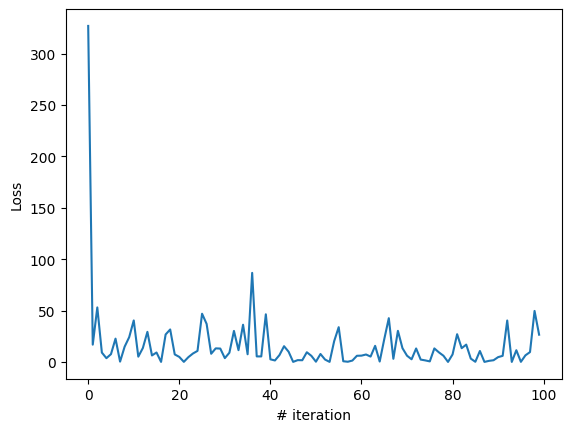

In [30]:
(w1, w2, w3, b, losses) = implement_linear_regression(X, y)
plt.plot(losses[:100])
plt.xlabel("# iteration")
plt.ylabel("Loss")
plt.show()

In [32]:
#Question 8:
X,y = prepare_data('/content/drive/MyDrive/advertising.csv')
(w1,w2,w3,b, losses) = implement_linear_regression(X,y)
print(w1,w2,w3)

0.07405984066396477 0.15917360263437663 0.017561197559948935


#### Inference

In [33]:
#Question 9:

tv = 19.2
radio = 35.9
newspaper = 51.3

X,y = prepare_data('/content/drive/MyDrive/advertising.csv')
(w1,w2,w3,b, losses) = implement_linear_regression(X,y)
sales = predict(tv, radio, newspaper, w1, w2, w3, b)
print(f'predicted sales is {sales}')

predicted sales is 8.176413319549823


In [36]:
def compute_loss_mae(y_hat, y):
  return abs(y_hat - y)

In [37]:
#Question 10:
l = compute_loss_mae(y_hat=1, y=0.5)
print(l)

0.5


Question 3

In [46]:

def implement_linear_regression_nsamples(X_data, y_data, epoch_max = 50,lr = 0.00001):
  losses = []

  w1, w2, w3, b = initialize_params()
  N = len(y_data)

  for epoch in range(epoch_max):

      loss_total = 0.0
      dw1_total = 0.0
      dw2_total = 0.0
      dw3_total = 0.0
      db_total  = 0.0

      for i in range(N):
          # get a sample
          x1 = X_data[0][i]
          x2 = X_data[1][i]
          x3 = X_data[2][i]

          y  = y_data[i]

          # print(y)
          # compute output
          y_hat = predict(x1, x2, x3, w1, w2, w3, b)

          # compute loss
          loss = compute_loss_mae(y, y_hat)
          loss_total += loss

          # compute gradient w1, w2, w3, b
          dl_dw1 = compute_gradient_wi(x1, y, y_hat)
          dl_dw2 = compute_gradient_wi(x2, y, y_hat)
          dl_dw3 = compute_gradient_wi(x3, y, y_hat)
          dl_db  = compute_gradient_b(y, y_hat)

          # accumulate loss to total loss
          dw1_total += dl_dw1
          dw2_total += dl_dw2
          dw3_total += dl_dw3
          db_total  += dl_db

          #(after processing N samples) - update parameters
          w1 = update_weight_wi(w1, dl_dw1/N, lr)
          w2 = update_weight_wi(w2, dl_dw2/N, lr)
          w3 = update_weight_wi(w3, dl_dw3/N, lr)
          b  = update_weight_b(b, dl_db/N, lr)

          # logging
          losses.append(loss_total/N)
  return (w1,w2,w3,b, losses)

In [52]:
#Question 11:
X,y = prepare_data('/content/drive/MyDrive/advertising.csv')
(w1,w2,w3,b, losses) = implement_linear_regression_nsamples(X,y,epoch_max=1000, lr = 0.00001)
print(w1,w2,w3)

0.06723890480573061 0.15769439817251044 0.029487025357455968


Question 4

In [60]:
def prepare_data(file_name_dataset):
  data = np.genfromtxt(file_name_dataset, delimiter=',', skip_header=1).tolist()

  tv_data = get_column(data, 0)

  radio_data = get_column(data, 1)

  newspaper_data = get_column(data, 2)

  sales_data = get_column(data, 3)

  X = [[1, x1, x2, x3] for x1, x2, x3 in zip(tv_data, radio_data, newspaper_data)]
  y = sales_data
  return X,y

In [61]:
def initialize_params():
    bias = 0
    w1 = random.gauss(mu=0.0, sigma=0.01)
    w2 = random.gauss(mu=0.0, sigma=0.01)
    w3 = random.gauss(mu=0.0, sigma=0.01)

    return [0, 0.016992259082509283, 0.0070783670518262355, -0.002307860847821344]

In [63]:
def predict(X_features, weights):
  return sum([f*w for f, w in zip(X_features, weights)])

def compute_loss(y_hat, y):
    return (y_hat - y)**2

def compute_gradient_w(X_features, y, y_hat):
  dl_dweights = [2*xi*(y_hat-y) for xi in X_features]
  return dl_dweights

def update_weight(weights, dl_dweights, lr):
  weights = [w - lr*dw for w, dw in zip(weights, dl_dweights)]
  return weights

In [68]:
def implement_linear_regression(X_feature, y_ouput, epoch_max = 50,lr = 1e-5):

  losses = []
  weights = initialize_params()
  N = len(y_ouput)
  for epoch in range(epoch_max):
      print("epoch", epoch)
      for i in range(N):
          features_i = X_feature[i]
          y = y_ouput[i]

          y_hat = predict(features_i, weights)

          loss = compute_loss(y, y_hat)

          dl_dweights = compute_gradient_w(features_i, y, y_hat)

          weights = update_weight(weights, dl_dweights, lr)

          losses.append(loss)
  return weights, losses

epoch 0
epoch 1
epoch 2
epoch 3
epoch 4
epoch 5
epoch 6
epoch 7
epoch 8
epoch 9
epoch 10
epoch 11
epoch 12
epoch 13
epoch 14
epoch 15
epoch 16
epoch 17
epoch 18
epoch 19
epoch 20
epoch 21
epoch 22
epoch 23
epoch 24
epoch 25
epoch 26
epoch 27
epoch 28
epoch 29
epoch 30
epoch 31
epoch 32
epoch 33
epoch 34
epoch 35
epoch 36
epoch 37
epoch 38
epoch 39
epoch 40
epoch 41
epoch 42
epoch 43
epoch 44
epoch 45
epoch 46
epoch 47
epoch 48
epoch 49


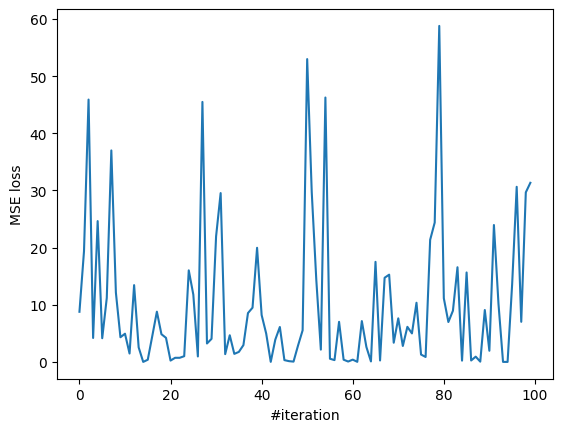

In [69]:
X, y = prepare_data('/content/drive/MyDrive/advertising.csv')
weights, losses = implement_linear_regression(X, y)

plt.plot(losses[-100:])
plt.xlabel("#iteration")
plt.ylabel("MSE loss")
plt.show()

In [70]:
#Question 12:
X,y = prepare_data('/content/drive/MyDrive/advertising.csv')
W,L = implement_linear_regression(X,y)
print(L[9999])

epoch 0
epoch 1
epoch 2
epoch 3
epoch 4
epoch 5
epoch 6
epoch 7
epoch 8
epoch 9
epoch 10
epoch 11
epoch 12
epoch 13
epoch 14
epoch 15
epoch 16
epoch 17
epoch 18
epoch 19
epoch 20
epoch 21
epoch 22
epoch 23
epoch 24
epoch 25
epoch 26
epoch 27
epoch 28
epoch 29
epoch 30
epoch 31
epoch 32
epoch 33
epoch 34
epoch 35
epoch 36
epoch 37
epoch 38
epoch 39
epoch 40
epoch 41
epoch 42
epoch 43
epoch 44
epoch 45
epoch 46
epoch 47
epoch 48
epoch 49
31.338878034644296
